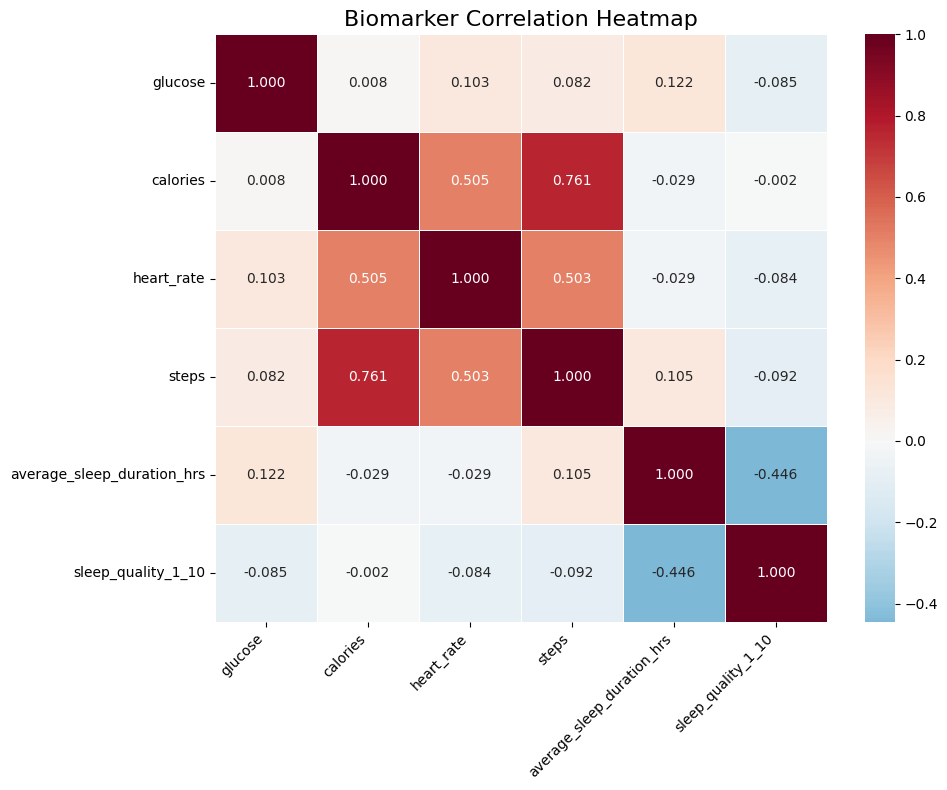

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Data/cleaned/Team01_PYVoyagers_cleaned_data.csv")

# Define the columns
cols = ['glucose', 'calories', 'heart_rate', 'steps', 'average_sleep_duration_hrs', 'sleep_quality_1_10']

# Calculate the correlation matrix
corr_matrix = df[cols].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Create a heatmap using Seaborn
# 'annot=True' displays the numbers, 'cmap' sets the color scheme (Red-Blue)
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".3f", linewidths=0.5)

# Adding titles and labels for a professional look
plt.title('Biomarker Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save and show
#plt.savefig('biomarker_correlation_heatmap.png')
plt.show()

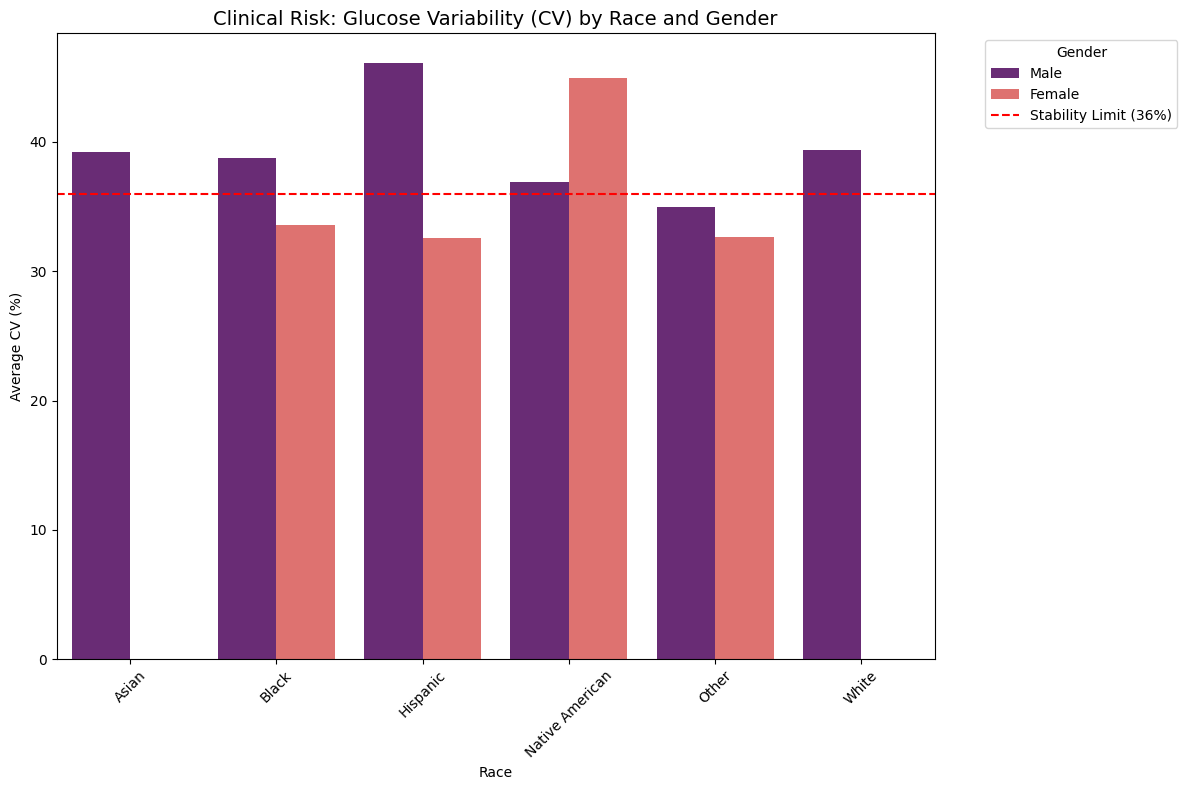

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CALCULATE the CV by Patient
df_cv = df.groupby(['patient_id', 'race', 'gender']).agg(
    glucose_mean=('glucose', 'mean'),
    glucose_std=('glucose', 'std')
).reset_index()

# Calculate CV
df_cv['glucose_cv'] = (df_cv['glucose_std'] / df_cv['glucose_mean']) * 100

# 2. GROUP for the visualization (Race and Gender only)
# We calculate the average CV for each Race/Gender combination
race_gender_cv = df_cv.groupby(['race', 'gender'])['glucose_cv'].mean().reset_index()

# 3. PLOT the Graph
plt.figure(figsize=(12, 8)) # Controlled size for a single chart

sns.barplot(
    data=race_gender_cv, 
    x='race', 
    y='glucose_cv', 
    hue='gender', 
    palette='magma'
)

# Add the clinical threshold line (36%)
plt.axhline(36, color='red', linestyle='--', label='Stability Limit (36%)')

# Formatting adjustments
plt.title('Clinical Risk: Glucose Variability (CV) by Race and Gender', fontsize=14)
plt.ylabel('Average CV (%)')
plt.xlabel('Race')
plt.xticks(rotation=45)

# Place legend outside or in a clear spot
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
